<h2 style="text-align:center;"> HELLENIC OPEN UNIVERSITY - SCHOOL OF SCIENCE AND TECHNOLOGY</h2>
<h2 style="text-align:center;"> DATA SCIENCE AND MACHINE LEARNING : DAMA61 ACAD. YEAR 2025-26</h2>

<h3 style="text-align:center;"> WRITTEN ASSIGNMENT 2 - Solutions</h3>

### Helpful configurations

In [1]:
# increase the width of the notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

### Problem 1

In this problem, you will apply Linear, Ridge, and Lasso models to predict the median house value based on california_housing dataset.

1) Load the California Housing dataset using fetch_california_housing() as a dataframe from the <i>sklearn.datasets</i> subpackage. Inspect the dataset by reporting its shape, missing values, and variable types. Handle missing or categorical data appropriately (if any). <b>[10%]</b>

2) Use the MedHouseVal (median house value) as the target value and the rest of the columns of the dataframe as the input features. Split the data into training (70%) and testing (30%) sets. Apply feature scaling to standardize input variables. <b>[20%]</b>

3) Train a simple Linear Regression model. This will serve as a baseline. Evaluate the performance of this model by presenting its Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Coefficient of Determination (R²) on the test set, and plot the ground truth median house values against the predicted ones. <b>[20%]</b>

4) Now train a Ridge Regression and a Lasso Regression model using different values of the regularization parameter alpha (alpha = 0.001, 0.01, 0.1, 1, 10). Use a 5-fold GridSearchCV to select the optimal alpha value for each model. Evaluate the best Ridge and the best Lasso model by presenting their Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Coefficient of Determination (R²) on the test set, and plot the ground truth median house values against the predicted ones. <b>[30%]</b>

5) Compare your results between the three models (Linear, Ridge, and Lasso) by presenting the coefficients of each model. Discuss and comment on the effect of the regularization parameter (alpha) in Ridge and Lasso Regression. <b>[20%]</b>

### Question 1

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.pipeline import Pipeline

In [3]:
# Load the dataset as a pandas DataFrame
cal = fetch_california_housing(as_frame = True)

df_cal = cal.frame  # contains the input features and the target values

print(f"Shape: {df_cal.shape}")
df_cal.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Check for missing values
df_cal.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [5]:
# Print the data type of each column
df_cal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


We observe that the dataset contains 20640 of 8 numerical features. There are no missing values.

### Question 2

In [6]:
# Feature - target separation
X_cal = df_cal.drop(columns=["MedHouseVal"])  # target column name in this dataset
y_cal = df_cal["MedHouseVal"]

# Train/test split (70/30)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_cal, y_cal, test_size=0.30, random_state=42)

# Data scaling
scaler = StandardScaler()
Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)

### Question 3

In [7]:
# Create a pipeline with preprocessing and Linear Regression
lin_reg = LinearRegression()

# Train the model
lin_reg.fit(Xc_train_scaled, yc_train)

# Predict on test data
y_pred_lin = lin_reg.predict(Xc_test_scaled)

In [8]:
# Evaluate model performance
mse = mean_squared_error(yc_test, y_pred_lin)
rmse = np.sqrt(mean_squared_error(yc_test, y_pred_lin))
r2 = r2_score(yc_test, y_pred_lin)

print(f"Linear Regression — MSE: {mse:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

Linear Regression — MSE: 0.5306, RMSE: 0.7284, R²: 0.5958


In [9]:
# Plot true vs predicted values
# Based on questions 4 and 5, we need to plot the ground truth vs the prediced mean house value for all 
# the three models (Linear, Ridge Lasso). Thus it is a good idea to create a function for these plots.

def plot_true_vs_pred(y_true, y_pred, title):

    plt.figure(figsize=(6, 6))
    plt.title(title)

    plt.scatter(y_true, y_pred, alpha=0.5)

    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

    plt.xlabel("Ground truth values")
    plt.ylabel("Predicted Values")
    plt.grid()
    plt.show()

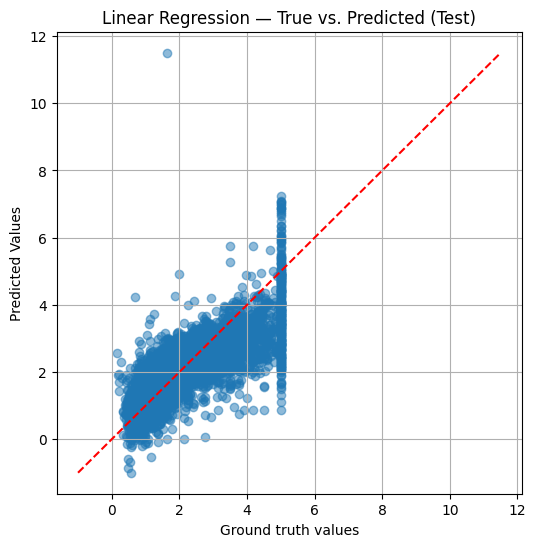

In [10]:
# Plot true vs predicted values - Linear model
plot_true_vs_pred(yc_test, y_pred_lin, title = "Linear Regression — True vs. Predicted (Test)")

### Question 4

Best Lasso alpha: 0.001
Ridge Regression (best alpha) — MSE: 0.5306, RMSE: 0.7284, R²: 0.5958


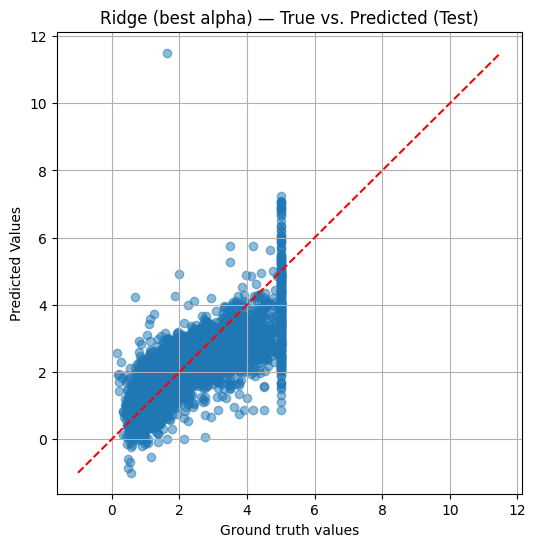

In [11]:
# Ridge Regression with cross-validation
# Now that we are applying cross-validation, we need to ensure that the Standard Scaler is fitted 
# only on the training set of each fold, and then use that transformation to scale the corresponding test set.
# Thus we will use a pipeline.

pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("model", Ridge())
])

# Define parameter grid for alpha
cv_params = {"model__alpha": np.logspace(-3, 1, 5)}

# Grid search with 5-fold cross-validation
ridge_grid = GridSearchCV(pipeline,
                          param_grid = cv_params,
                          scoring = "neg_mean_squared_error",
                          cv = 5,
                          n_jobs = -1)

# Train the Lasso model on the original data. The pipeline will apply a scaler before training.
ridge_grid.fit(Xc_train, yc_train)

# Best alpha
print("Best Lasso alpha:", ridge_grid.best_params_["model__alpha"])

# Predict on test data
y_pred_ridge = ridge_grid.predict(Xc_test)

# Evaluate performance
mse = mean_squared_error(yc_test, y_pred_ridge)
rmse = np.sqrt(mse)  
r2 = r2_score(yc_test, y_pred_ridge)

print(f"Ridge Regression (best alpha) — MSE: {mse:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# Plot True vs Predicted
plot_true_vs_pred(yc_test, y_pred_ridge, title="Ridge (best alpha) — True vs. Predicted (Test)")

Best Lasso alpha: 0.001
Lasso Regression (best alpha) — MSE: 0.5297, RMSE: 0.7278, R²: 0.5964


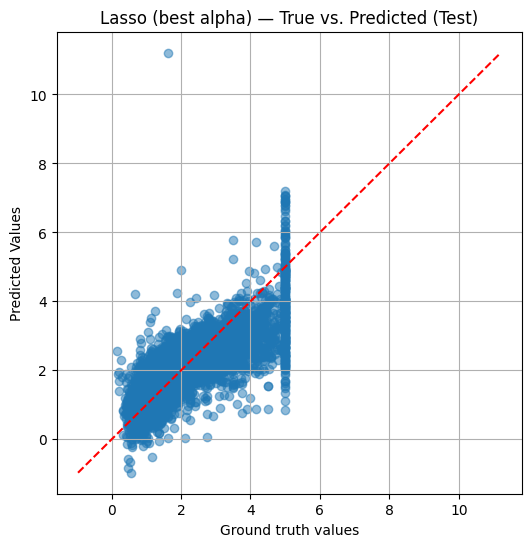

In [12]:
# Lasso Regression with cross-validation

pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("model", Lasso())
])


# Define parameter grid for alpha
cv_params = {"model__alpha": np.logspace(-3, 1, 5)}

# Grid search with 5-fold cross-validation
lasso_grid = GridSearchCV(pipeline,
                          param_grid = cv_params,
                          scoring = "neg_mean_squared_error",
                          cv = 5,
                          n_jobs = -1)

# Train the Lasso model on the original data. The pipeline will apply a scaler before training.
lasso_grid.fit(Xc_train, yc_train)

# Best alpha
print("Best Lasso alpha:", lasso_grid.best_params_["model__alpha"])

# Predict on test data
y_pred_lasso = lasso_grid.predict(Xc_test)

# Evaluate performance
mse = mean_squared_error(yc_test, y_pred_lasso)
rmse = np.sqrt(mse)  
r2 = r2_score(yc_test, y_pred_lasso)

print(f"Lasso Regression (best alpha) — MSE: {mse:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# Plot True vs Predicted
plot_true_vs_pred(yc_test, y_pred_lasso, title="Lasso (best alpha) — True vs. Predicted (Test)")

### Question 5

In [13]:
# Linear model's coefficients
lin_coefs = lin_reg.coef_
print("Linear:", lin_coefs)

# Ridge model's coefficients (we need to get them through the grid search proccess)
rid_coefs = ridge_grid.best_estimator_['model'].coef_
print("Ridge:", rid_coefs)

# Lasso model's coefficients (we need to get them through the grid search proccess)
las_coefs = lasso_grid.best_estimator_['model'].coef_
print("Lasso:", las_coefs)

# Input feature's name
features = X_cal.columns.values
print("Features:", features)

Linear: [ 8.49221760e-01  1.22119309e-01 -2.99558449e-01  3.48409673e-01
 -8.84488134e-04 -4.16980388e-02 -8.93855649e-01 -8.68616688e-01]
Ridge: [ 8.49221691e-01  1.22119398e-01 -2.99558200e-01  3.48409366e-01
 -8.84457755e-04 -4.16980432e-02 -8.93854796e-01 -8.68615823e-01]
Lasso: [ 0.84390401  0.12280902 -0.28584776  0.33457952 -0.         -0.04071854
 -0.8830857  -0.85715141]
Features: ['MedInc' 'HouseAge' 'AveRooms' 'AveBedrms' 'Population' 'AveOccup'
 'Latitude' 'Longitude']


In [14]:
# For a better visualization we can create a pd.Dataframe
coefs = pd.DataFrame.from_dict({'Linear': lin_coefs, 'Ridge': rid_coefs, 'Lasso': las_coefs})
coefs.set_index(features)

,Linear,Ridge,Lasso
MedInc,0.849222,0.849222,0.843904
HouseAge,0.122119,0.122119,0.122809
AveRooms,-0.299558,-0.299558,-0.285848
AveBedrms,0.348410,0.348409,0.334580
Population,-0.000884,-0.000884,-0.000000
AveOccup,-0.041698,-0.041698,-0.040719
Latitude,-0.893856,-0.893855,-0.883086
Longitude,-0.868617,-0.868616,-0.857151


We observe that all models provide similar results and draw similar coefficients. It is worth mentioning that Lasso pushes the coefficient of the Population feature to zero, demonstrating its feature selection ability.

### Problem 2

In this problem, you will apply Linear SVMs and RBF SVMs to the Banknote Authentication dataset (https://archive.ics.uci.edu/ml/datasets/banknote+authentication). The dataset contains four real-valued wavelet features extracted from banknote images and a binary label indicating whether a banknote is genuine or counterfeit. You will work with a 2D projection of the data for visualization and classifier comparison.

1) Load the Banknote Authentication dataset using fetch_openml("banknote-authentication") as a dataframe from the <i>sklearn.datasets</i> subpackage and select Variance (V1) and Curtosis (V3) as the two features for analysis. <b>[5%]</b>

2) Perform basic exploratory data analysis by reporting the number of samples in each class, the mean, standard deviation, and range of each feature, the correlation between Variance and Curtosis, check for any missing values, and comment on your results. <b>[10%]</b>

3) Create a scatter plot with Variance on the x-axis and Curtosis on the y-axis, using different colors to distinguish genuine and counterfeit banknotes. Additionally, plot kernel density estimates (KDE), using a Gaussian kernel for each class to identify overlapping regions. Place all three plots side by side. Based on the visualization, discuss whether the two classes appear linearly separable. <b>[5%]</b>

4) Standardize the two selected features and train two Linear SVM models with regularization parameters $C = 0.01$ and $C = 1000$, respectively. Report the number of support vectors and the training F1-score for each model. <b>[10%]</b>

5) For each model, produce a plot showing the standardized data points, the decision boundary, the margins, and highlight the support vectors. Discuss how the choice of C affects the margin width, the number of support vectors, and the potential for overfitting or underfitting. <b>[10%]</b>

6) Perform a 5-fold cross-validation grid search to train RBF SVM models using the hyperparameter combinations $C \in \{0.1, 1, 10, 100\}$ and $\gamma \in \{0.1, 1, 10, 100\}$. Identify the best combination of $C$ and $\gamma$ according to the training F1-score. For the best RBF SVM model, report the number of support vectors and the training F1-score, and create a plot showing the decision boundary together with the two-dimensional dataset. <b>[20%]</b>

7) Split the dataset, using stratified splitting, into training (80%) and test (20%) sets and train a Linear SVC with $C=10$ and an RBF SVC with the best $C$ value of the previous question. <b>[20%]</b>

8) For each model, evaluate its generalization performance by presenting the F1-score for the training and the test set, along with its classification report on the test set. Finally, discuss why an RBF kernel might outperform a linear kernel and how linear separability in two dimensions compares to separability in higher dimensions. <b>[20%]</b>

<i>Hint: Fix the random state to 42 where appropriate.</i>

### Question 1

In [15]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import f1_score, classification_report

In [16]:
# Load Banknote Authentication dataset
banknote = fetch_openml("banknote-authentication", as_frame=True)

# Select two features for analysis: Variance and Curtosis
X = banknote.data[['V1', 'V3']]
y = banknote.target.astype(int)

# Rename columns for clarity
X = X.rename(columns={'V1': 'variance', 'V3': 'curtosis'})

### Question 2

In [17]:
# Explore the dataset
X.head()

,variance,curtosis
0,3.62160,-2.8073
1,4.54590,-2.4586
2,3.86600,1.9242
3,3.45660,-4.0112
4,0.32924,4.5718


In [18]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Class, dtype: int64

In [19]:
print("Class counts:")
print(y.value_counts())

Class counts:
Class
1    762
2    610
Name: count, dtype: int64


In [20]:
print("\nFeature statistics:")
print(X.describe())


Feature statistics:
          variance     curtosis
count  1372.000000  1372.000000
mean      0.433735     1.397627
std       2.842763     4.310030
min      -7.042100    -5.286100
25%      -1.773000    -1.574975
50%       0.496180     0.616630
75%       2.821475     3.179250
max       6.824800    17.927400


In [21]:
print("\nCorrelation between features:")
print(X.corr())


Correlation between features:
          variance  curtosis
variance   1.00000  -0.38085
curtosis  -0.38085   1.00000


In [22]:
# Check for missing values
print("\nMissing values:")
print(X.isnull().sum())


Missing values:
variance    0
curtosis    0
dtype: int64


The exploratory data analysis shows that the Banknote Authentication dataset contains 762 samples in class 1 (genuine) and 610 samples in class 2 (counterfeit), indicating a slight imbalance. Feature statistics reveal that 'Variance' and 'Curtosis' have different scales. This suggests that standardizing the data may be necessary before training any models. Finally, there is a moderate negative correlation between Variance and Curtosis, with a value of -0.38085.

### Question 3

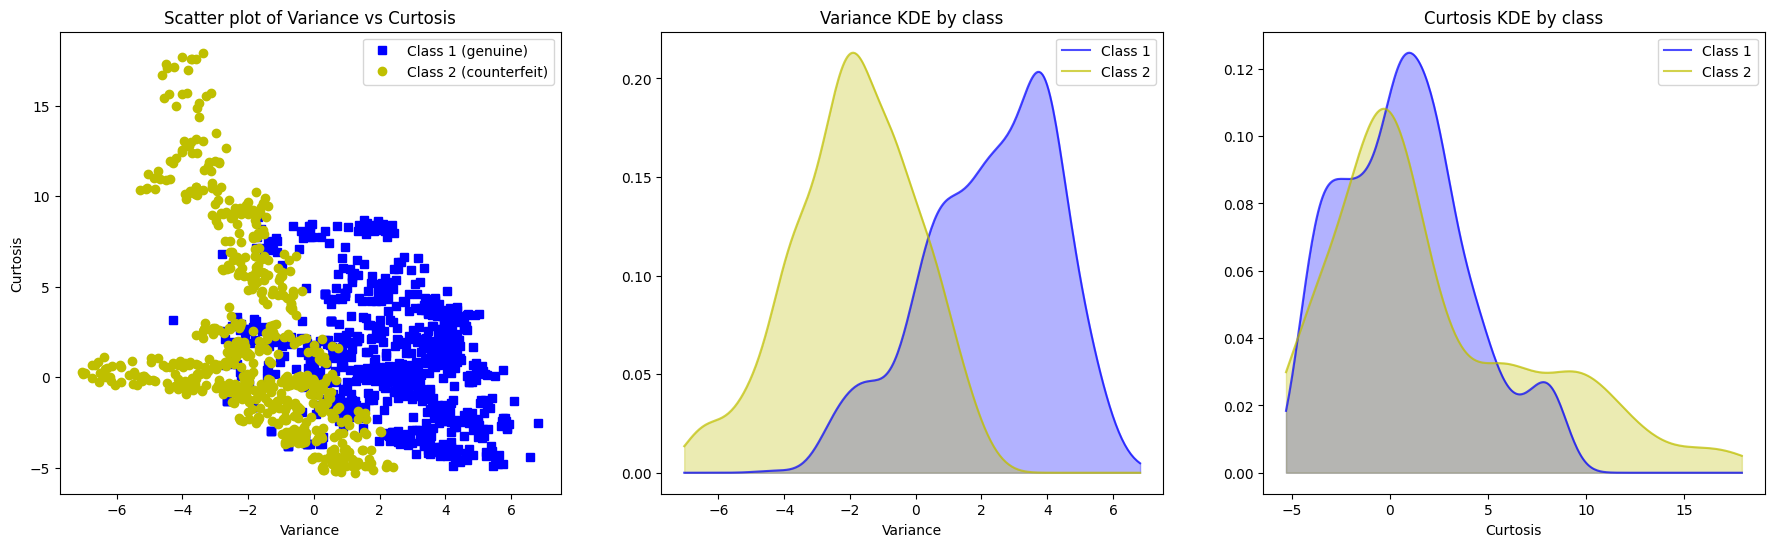

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Split by class
var_1 = X[y == 1]['variance'].values
var_2 = X[y == 2]['variance'].values

cur_1 = X[y == 1]['curtosis'].values
cur_2 = X[y == 2]['curtosis'].values

fig, ax = plt.subplots(1, 3, figsize=(22, 6))

# Scatter plot
ax[0].plot(var_1, cur_1, 'bs', label='Class 1 (genuine)')
ax[0].plot(var_2, cur_2, 'yo', label='Class 2 (counterfeit)')
ax[0].set_xlabel("Variance")
ax[0].set_ylabel("Curtosis")
ax[0].set_title("Scatter plot of Variance vs Curtosis")
ax[0].legend()

# Variance
x_range_var = np.linspace(X['variance'].min(), X['variance'].max(), 300)

kde_var_1 = gaussian_kde(var_1)
kde_var_2 = gaussian_kde(var_2)

ax[1].plot(x_range_var, kde_var_1(x_range_var), c='b', alpha = 0.7, label='Class 1')
ax[1].plot(x_range_var, kde_var_2(x_range_var), c='y', alpha = 0.7, label='Class 2')
ax[1].fill_between(x_range_var, kde_var_1(x_range_var), color = 'b', alpha=0.3)
ax[1].fill_between(x_range_var, kde_var_2(x_range_var), color = 'y', alpha=0.3)
ax[1].set_title("Variance KDE by class")
ax[1].set_xlabel("Variance")
ax[1].legend()

# Curtosis
x_range_cur = np.linspace(X['curtosis'].min(), X['curtosis'].max(), 300)

kde_cur_1 = gaussian_kde(cur_1)
kde_cur_2 = gaussian_kde(cur_2)

ax[2].plot(x_range_cur, kde_cur_1(x_range_cur), c='b', alpha=0.7, label='Class 1')
ax[2].plot(x_range_cur, kde_cur_2(x_range_cur), c='y', alpha=0.7, label='Class 2')
ax[2].fill_between(x_range_cur, kde_cur_1(x_range_cur), color = 'b', alpha=0.3)
ax[2].fill_between(x_range_cur, kde_cur_2(x_range_cur), color = 'y', alpha=0.3)
ax[2].set_title("Curtosis KDE by class")
ax[2].set_xlabel("Curtosis")
ax[2].legend()

plt.show()


The scatter plot and Kernel Density Estimates (KDE) clearly illustrate that the two classes are not linearly separable in this 2D space, as there is a significant overlapping region where data points from both classes are intermixed. The KDE plots quantify this overlap, suggesting that a linear classifier will likely struggle to achieve high separation performance.

### Question 4

In [24]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check the standardized data
print("Mean of scaled features:", X_scaled.mean(axis=0))
print("Std of scaled features:", X_scaled.std(axis=0))

Mean of scaled features: [-8.28621266e-17 -6.21465950e-17]
Std of scaled features: [1. 1.]


In [25]:
# Train Linear SVM with C=0.01
lin_svm_lowC = SVC(kernel='linear', C=0.01)
lin_svm_lowC.fit(X_scaled, y)
print(f"Linear SVM C=0.01 support vectors: {len(lin_svm_lowC.support_)}")
print(f"Training F1-score: {f1_score(y, lin_svm_lowC.predict(X_scaled)):.3f}")

Linear SVM C=0.01 support vectors: 696
Training F1-score: 0.882


In [26]:
# Train Linear SVM with C=1000
lin_svm_highC = SVC(kernel='linear', C=1000)
lin_svm_highC.fit(X_scaled, y)

print(f"Linear SVM C=1000 support vectors: {len(lin_svm_highC.support_)}")
print(f"Training F1-score: {f1_score(y, lin_svm_highC.predict(X_scaled)):.3f}")

Linear SVM C=1000 support vectors: 446
Training F1-score: 0.888


### Question 5

In [27]:
# Function to plot linear SVM decision boundary  
def plot_linear_svm(model, X, y, xmin, xmax, ymin, ymax, title):
    plt.figure(figsize=(8,6))
    
    # Plot data points
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], 'bs')
    plt.plot(X[:, 0][y==2], X[:, 1][y==2], 'yo')

    # Extract weights and bias
    w = model.coef_[0]
    b = model.intercept_[0]

    # Compute decision boundary line
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1]

    # Margins
    margin = 1 / w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin

    # Plot decision boundary and margins
    plt.plot(x0, decision_boundary, "k-", linewidth=2, zorder=-2, label='Decision boundary')
    plt.plot(x0, gutter_up, "k--", linewidth=2, zorder=-2, label='Margin')
    plt.plot(x0, gutter_down, "k--", linewidth=2, zorder=-2)

    # Highlight support vectors
    svs = model.support_vectors_
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#AAA', zorder=-1, label='Support Vectors')

    plt.title(title)
    plt.xlabel('Variance (standardized)')
    plt.ylabel('Curtosis (standardized)')
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.legend()
    plt.show()

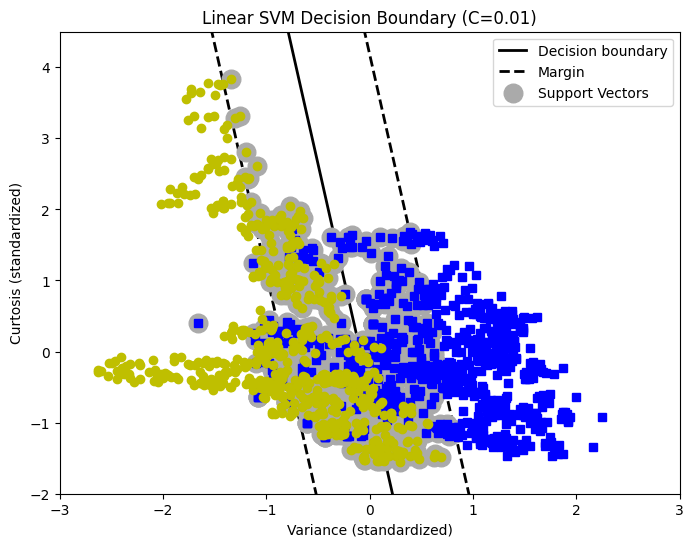

In [28]:
plot_linear_svm(lin_svm_lowC, X_scaled, y, -3, 3, -2 , 4.5, "Linear SVM Decision Boundary (C=0.01)")

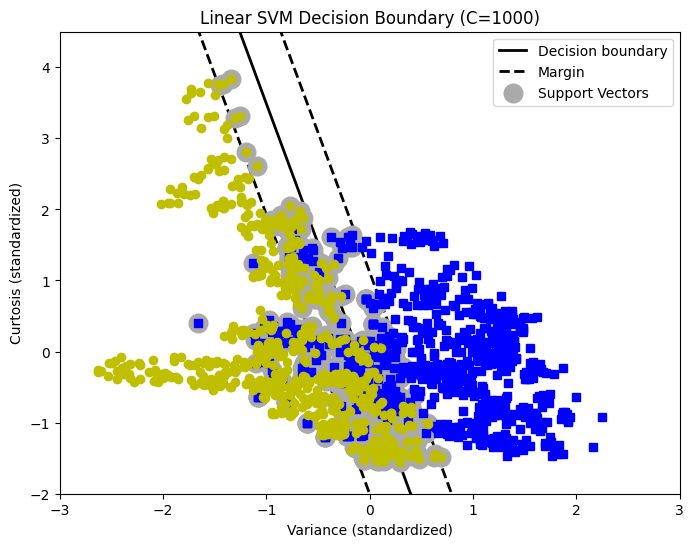

In [29]:
plot_linear_svm(lin_svm_highC, X_scaled, y, -3, 3, -2 , 4.5, "Linear SVM Decision Boundary (C=1000)")

Training two Linear SVM models with different regularization parameters, C=0.01 (low) and C=1000 (high), demonstrates the effect of C on the model. With a low C (C=0.01), the model is forced to tolerate more misclassifications to achieve a wider margin, resulting in 696 support vectors and a training F1-score of 0.882. This model is more regularized and aims for better generalization, potentially underfitting slightly. Conversely, a high C (C=1000) attempts to classify nearly all points correctly, resulting in a narrower margin and a lower number of support vectors (446) and a similar training F1-score of 0.888. Both linear models show comparable performance, but the C=0.01 model, with its wider margin and greater number of support vectors, may be considered more robust due to its higher regularization, reducing the risk of overfitting to the training data.

### Question 6

In [30]:
# Grid search for RBF SVM
param_grid = {'model__C':[0.1, 1, 10, 100], 'model__gamma':[0.1, 1, 10, 100]}

rbf_svm = Pipeline([
    ("scale", StandardScaler()),
    ("model", SVC(kernel='rbf'))
])

grid_search = GridSearchCV(rbf_svm, param_grid, scoring='f1', cv=5)
grid_search.fit(X, y)

best_rbf = grid_search.best_estimator_['model']
print(f"Best RBF SVM parameters: {grid_search.best_params_}")
print(f"Number of support vectors: {len(best_rbf.support_)}")
print(f"Training F1-score: {f1_score(y, best_rbf.predict(X_scaled)):.4f}")

Best RBF SVM parameters: {'model__C': 10, 'model__gamma': 10}
Number of support vectors: 379
Training F1-score: 0.9296


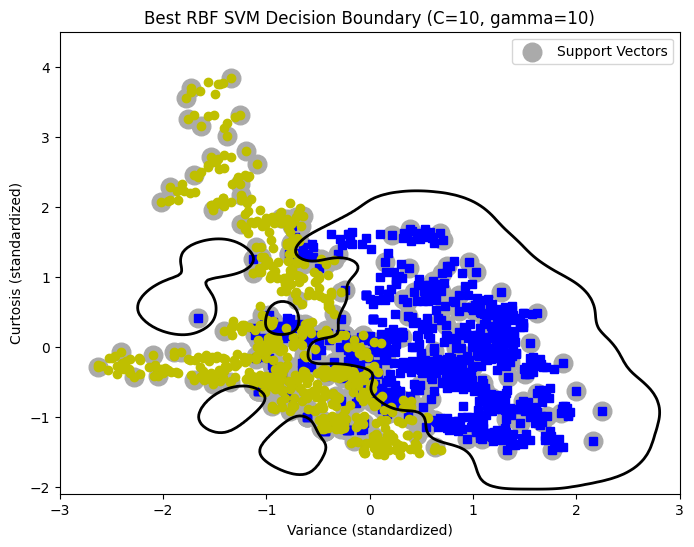

In [31]:
# Function to plot RBF SVM decision boundary
def plot_rbf_svm(model, X, y, xmin, xmax, ymin, ymax, title):
    plt.figure(figsize=(8,6))
    
    # Plot data points
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], 'bs')
    plt.plot(X[:, 0][y==2], X[:, 1][y==2], 'yo')

    # Support vectors
    svs = model.support_vectors_
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#AAA', zorder=-1, label='Support Vectors')

    # Create a grid
    xx, yy = np.meshgrid(np.linspace(xmin, xmax, 200),
                         np.linspace(ymin, ymax, 200))
    
    # Decision function
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)
    
    plt.title(title)
    plt.xlabel('Variance (standardized)')
    plt.ylabel('Curtosis (standardized)')
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.legend()
    plt.show()

plot_rbf_svm(best_rbf, X_scaled, y, -3, 3, -2.1, 4.5,
             f"Best RBF SVM Decision Boundary (C={grid_search.best_params_['model__C']}, gamma={grid_search.best_params_['model__gamma']})")

### Question 7

In [32]:
# Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lin_svm = SVC(kernel='linear', C=10)
lin_svm.fit(X_train, y_train)

y_train_pred = lin_svm.predict(X_train)
y_test_pred = lin_svm.predict(X_test)

# Evaluate
print(f"Linear SVM (C=10) - Training F1-score: {f1_score(y_train, y_train_pred):.4f}")
print(f"Linear SVM (C=10) - Test F1-score: {f1_score(y_test, y_test_pred):.4f}")

print("\nClassification report (test set):")
print(classification_report(y_test, y_test_pred))

Linear SVM (C=10) - Training F1-score: 0.8910
Linear SVM (C=10) - Test F1-score: 0.8935

Classification report (test set):
              precision    recall  f1-score   support

           1       0.94      0.85      0.89       153
           2       0.83      0.93      0.88       122

    accuracy                           0.89       275
   macro avg       0.89      0.89      0.89       275
weighted avg       0.89      0.89      0.89       275



In [33]:
rbf_svm = SVC(kernel='rbf', C=10)
rbf_svm.fit(X_train, y_train)

# Predictions
y_train_pred = rbf_svm.predict(X_train)
y_test_pred = rbf_svm.predict(X_test)

# Evaluate
print(f"RBF SVM (C=10) - Training F1-score: {f1_score(y_train, y_train_pred):.4f}")
print(f"RBF SVM (C=10) - Test F1-score: {f1_score(y_test, y_test_pred):.4f}")

print("\nClassification report (test set):")
print(classification_report(y_test, y_test_pred))

RBF SVM (C=10) - Training F1-score: 0.9012
RBF SVM (C=10) - Test F1-score: 0.9268

Classification report (test set):
              precision    recall  f1-score   support

           1       0.99      0.87      0.93       153
           2       0.86      0.99      0.92       122

    accuracy                           0.92       275
   macro avg       0.93      0.93      0.92       275
weighted avg       0.93      0.92      0.92       275



### Question 8

Evaluating the models on a train/test split shows that the RBF SVM slightly outperforms the Linear SVM. Both models maintain consistent performance, with training F1-scores of 0.9012 (RBF) and 0.8910 (Linear), and test F1-scores of 0.9268 (RBF) and 0.8935 (Linear), respectively. This indicates good generalization and little evidence of overfitting.

The main point is that the RBF kernel outperforms the linear kernel because it implicitly maps non-linearly separable 2D data into a higher-dimensional space, where the classes become linearly separable. This demonstrates the strength of kernel methods when working with non-linear data.